# Surface Water Fraction estimation
DD-JNB_SWF_v1   
This notebook demonstrates the Surface Water Fraction (SWF) retrieval algorithm developed for CIMR L2PAD. Estimating SWF involves calculating land reference emissivity based on soil moisture and vegetation optical depth conditions. The reference emissivities are stored in a pre-calculated Look-Up Table (LUT), created based on LPDR data (calculate_endmember_table.ipynb is included to document this step).

This prototype does not distinguish between frozen and non-frozen land conditions. Future versions will include a model for frozen land conditions and develop the uncertainty characterization.

This notebook applies the model to the TDS dataset, which consists on one day (July 15th, 2017) of gridded Windsat's 18.7 GHz TB (H and V-pol) and 36 GHz TB (V-pol) and derived SM and VOD data (LPDR data, Du et al., 2017). Future versions will further refine the approach using the CIMR hydrology target mask and include a quality-control to screen out frozen land conditions based on CIMR L2 TSA and FT products as well as other filters TBD.  


### Read input data that is required to run the SWF algorithm: 

- TB (H, V-pol) at K-band (18 GHz), 
- TB (V-pol) at Ka-band (36 GHz), 
- Vegetation Optical Depth (VOD) at X-band (10.8 GHz)
- Soil Moisture (SM)

In [ ]:
# Import necessary libraries
import os
import sys
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path

atbd_root_dir = Path(os.getcwd()).resolve().parent
sys.path.append(str(atbd_root_dir))

from algorithm.processing import colormaps
from algorithm.processing.validation_data_processing import load_lut, unravel_freqpol, atmospheric_corrections
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Open data
data_dir = os.path.join(os.getcwd(), '..', 'data')

# Load the LUT with reference land emissivities
lut_h_path = os.path.join(data_dir, 'lut_de_lannoy_K_h.csv')
lut_v_path = os.path.join(data_dir, 'lut_de_lannoy_K_v.csv')

tds_root = "https://thredds.met.no/thredds/fileServer/cimr/L2PAD/DI-TDS-JNB_V2D/"
swf_tds_file = "WINDSAT_DAILY_LST/CIMR_SWF_TDS_JNB_v2.nc"

tds_url = tds_root + swf_tds_file

# Try to open local dataset first, it's faster:
local_tds = os.path.join(atbd_root_dir, "data", "remote_data", "CIMR_SWF_TDS_JNB_v3.nc")

if os.path.exists(local_tds):
    print("Load local TDS")
    tds = xr.open_dataset(local_tds)
    print(f"Remote data also available at {tds_url}")
else:
    print("Local dataset not found, reading remote dataset")
    print(f"If this takes too much, download tds {tds_url}")
    print(f"And place it at {local_tds}")
    tds = xr.open_dataset(tds_url)

# NOTE: we need to normalize VOD between 0 and 1 from original LPDR's values: [0-3] Neper
min_val = 0
max_val = 3
old_attrs = tds.VOD.attrs
tds["VOD"] = (tds.VOD - min_val) /(max_val - min_val)

old_attrs.update(
    {
        "Valid_range": "1-0",
        "Description": "NORMALIZED VOD, original is 0-3 Neper", "Units": None
    }
)
tds.VOD.attrs = old_attrs

tds 


Load local TDS
Remote data also available at https://thredds.met.no/thredds/fileServer/cimr/L2PAD/DI-TDS-JNB_V2D/WINDSAT_DAILY_LST/CIMR_SWF_TDS_JNB_v2.nc


<xarray.Dataset> Size: 90MB
Dimensions:               (polarization: 2, frequency_band: 2, lat: 720,
                           lon: 1440)
Coordinates:
  * lat                   (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                   (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
    day_number            int64 8B ...
Dimensions without coordinates: polarization, frequency_band
Data variables:
    tbtoa                 (polarization, frequency_band, lat, lon) float32 17MB ...
    surtep_ERA5           (lat, lon) float32 4MB ...
    tran                  (polarization, frequency_band, lat, lon) float32 17MB ...
    tbdw                  (polarization, frequency_band, lat, lon) float32 17MB ...
    tbup                  (polarization, frequency_band, lat, lon) float32 17MB ...
    fwns                  (lat, lon) float32 4MB ...
    VOD                   (lat, lon) float32 4MB nan nan nan nan ... nan nan nan
    vsm                   (lat, lon) float32 4MB ...
    IGBP_landcover        (lat, lon) float32 4MB ...
    all_classes_area_pct  (lat, lon) uint8 1MB ...
    main_class            (lat, lon) uint8 1MB ...
    main_class_50pct      (lat, lon) uint8 1MB ...
Attributes: (12/72)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, Gl...
    Source_of_WindSat_L1C_TB:               T. Meissner et al., Remote Sensin...

In [40]:
tds = atmospheric_corrections(tds)
tds

<xarray.Dataset> Size: 123MB
Dimensions:               (polarization: 2, frequency_band: 2, lat: 720,
                           lon: 1440)
Coordinates:
  * lat                   (lat) float32 3kB -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                   (lon) float32 6kB -179.9 -179.6 -179.4 ... 179.6 179.9
    day_number            int64 8B ...
Dimensions without coordinates: polarization, frequency_band
Data variables: (12/14)
    tbtoa                 (polarization, frequency_band, lat, lon) float32 17MB ...
    surtep_ERA5           (lat, lon) float32 4MB ...
    tran                  (polarization, frequency_band, lat, lon) float32 17MB ...
    tbdw                  (polarization, frequency_band, lat, lon) float32 17MB ...
    tbup                  (polarization, frequency_band, lat, lon) float32 17MB ...
    fwns                  (lat, lon) float32 4MB ...
    ...                    ...
    IGBP_landcover        (lat, lon) float32 4MB ...
    all_classes_area_pct  (lat, lon) uint8 1MB ...
    main_class            (lat, lon) uint8 1MB ...
    main_class_50pct      (lat, lon) uint8 1MB ...
    tbboa_1st_order       (polarization, frequency_band, lat, lon) float32 17MB ...
    tbboa_de_lannoy       (lat, lon, polarization, frequency_band) float32 17MB ...
Attributes: (12/72)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, Gl...
    Source_of_WindSat_L1C_TB:               T. Meissner et al., Remote Sensin...

## Load Look up tables and create reference emissivity maps
Load CSV files and collocate reference emissivities for each observation  

NOTE: we create a new layer by indexing observations using VOD and SM, then
assign a value of reference emissivity according to the LUTs


In [41]:
tds = load_lut(tds, lut_filepath=lut_h_path)
tds = load_lut(tds, lut_filepath=lut_v_path)
tds

<xarray.Dataset> Size: 166MB
Dimensions:                      (polarization: 2, frequency_band: 2, lat: 720,
                                  lon: 1440)
Coordinates:
  * lat                          (lat) float32 3kB -89.88 -89.62 ... 89.62 89.88
  * lon                          (lon) float32 6kB -179.9 -179.6 ... 179.6 179.9
    day_number                   int64 8B 196
    sm_bin                       (lat, lon) int64 8MB -1 -1 -1 -1 ... -1 -1 -1
    vod_bin                      (lat, lon) int64 8MB -1 -1 -1 -1 ... -1 -1 -1
Dimensions without coordinates: polarization, frequency_band
Data variables: (12/16)
    tbtoa                        (polarization, frequency_band, lat, lon) float32 17MB ...
    surtep_ERA5                  (lat, lon) float32 4MB nan nan nan ... nan nan
    tran                         (polarization, frequency_band, lat, lon) float32 17MB ...
    tbdw                         (polarization, frequency_band, lat, lon) float32 17MB ...
    tbup                         (polarization, frequency_band, lat, lon) float32 17MB ...
    fwns                         (lat, lon) float32 4MB nan nan nan ... nan nan
    ...                           ...
    main_class                   (lat, lon) float32 4MB nan nan nan ... nan nan
    main_class_50pct             (lat, lon) float32 4MB nan nan nan ... nan nan
    tbboa_1st_order              (polarization, frequency_band, lat, lon) float32 17MB ...
    tbboa_de_lannoy              (lat, lon, polarization, frequency_band) float32 17MB ...
    ref_land_emis_de_lannoy_K_h  (lat, lon) float64 8MB nan nan nan ... nan nan
    ref_land_emis_de_lannoy_K_v  (lat, lon) float64 8MB nan nan nan ... nan nan
Attributes: (12/72)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, Gl...
    Source_of_WindSat_L1C_TB:               T. Meissner et al., Remote Sensin...

## SWF from  Difference Ratio in K band H-pol
Use xarray's in-build operators to get SWF

In [42]:
# unravel tbtoa layer into frequency and polarization arrays
tds = unravel_freqpol(tds, dvars=[
    "tbtoa", "tbboa_de_lannoy"
])

# Drop the multy dimentional dvars that we dont need anymore
tds = tds.drop_vars(["tbtoa", "tbboa_de_lannoy"])
tds

<xarray.Dataset> Size: 166MB
Dimensions:                      (lat: 720, lon: 1440, polarization: 2,
                                  frequency_band: 2)
Coordinates:
  * lat                          (lat) float32 3kB -89.88 -89.62 ... 89.62 89.88
  * lon                          (lon) float32 6kB -179.9 -179.6 ... 179.6 179.9
    day_number                   int64 8B 196
    sm_bin                       (lat, lon) int64 8MB -1 -1 -1 -1 ... -1 -1 -1
    vod_bin                      (lat, lon) int64 8MB -1 -1 -1 -1 ... -1 -1 -1
Dimensions without coordinates: polarization, frequency_band
Data variables: (12/22)
    surtep_ERA5                  (lat, lon) float32 4MB nan nan nan ... nan nan
    tran                         (polarization, frequency_band, lat, lon) float32 17MB ...
    tbdw                         (polarization, frequency_band, lat, lon) float32 17MB ...
    tbup                         (polarization, frequency_band, lat, lon) float32 17MB ...
    fwns                         (lat, lon) float32 4MB nan nan nan ... nan nan
    VOD                          (lat, lon) float32 4MB nan nan nan ... nan nan
    ...                           ...
    tbtoa37V                     (lat, lon) float32 4MB nan nan nan ... nan nan
    tbtoa37H                     (lat, lon) float32 4MB nan nan nan ... nan nan
    tbboa_de_lannoy19V           (lat, lon) float32 4MB nan nan nan ... nan nan
    tbboa_de_lannoy19H           (lat, lon) float32 4MB nan nan nan ... nan nan
    tbboa_de_lannoy37V           (lat, lon) float32 4MB nan nan nan ... nan nan
    tbboa_de_lannoy37H           (lat, lon) float32 4MB nan nan nan ... nan nan
Attributes: (12/72)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, Gl...
    Source_of_WindSat_L1C_TB:               T. Meissner et al., Remote Sensin...

In [43]:
# Get emissivity from TDS, Which has ERA5 skin temperature
for freq in ["19", "37"]:
    for pol in ["H", "V"]:
        tds[f"emiss{freq}{pol}_de_lannoy"] = tds[f"tbboa_de_lannoy{freq}{pol}"] / tds["surtep_ERA5"]

# Use IGBP to remove the ocean
tds = tds.where(tds.IGBP_landcover > 0)

tds

<xarray.Dataset> Size: 182MB
Dimensions:                      (lat: 720, lon: 1440, polarization: 2,
                                  frequency_band: 2)
Coordinates:
  * lat                          (lat) float32 3kB -89.88 -89.62 ... 89.62 89.88
  * lon                          (lon) float32 6kB -179.9 -179.6 ... 179.6 179.9
    day_number                   int64 8B 196
    sm_bin                       (lat, lon) int64 8MB -1 -1 -1 -1 ... -1 -1 -1
    vod_bin                      (lat, lon) int64 8MB -1 -1 -1 -1 ... -1 -1 -1
Dimensions without coordinates: polarization, frequency_band
Data variables: (12/26)
    surtep_ERA5                  (lat, lon) float32 4MB nan nan nan ... nan nan
    tran                         (polarization, frequency_band, lat, lon) float32 17MB ...
    tbdw                         (polarization, frequency_band, lat, lon) float32 17MB ...
    tbup                         (polarization, frequency_band, lat, lon) float32 17MB ...
    fwns                         (lat, lon) float32 4MB nan nan nan ... nan nan
    VOD                          (lat, lon) float32 4MB nan nan nan ... nan nan
    ...                           ...
    tbboa_de_lannoy37V           (lat, lon) float32 4MB nan nan nan ... nan nan
    tbboa_de_lannoy37H           (lat, lon) float32 4MB nan nan nan ... nan nan
    emiss19H_de_lannoy           (lat, lon) float32 4MB nan nan nan ... nan nan
    emiss19V_de_lannoy           (lat, lon) float32 4MB nan nan nan ... nan nan
    emiss37H_de_lannoy           (lat, lon) float32 4MB nan nan nan ... nan nan
    emiss37V_de_lannoy           (lat, lon) float32 4MB nan nan nan ... nan nan
Attributes: (12/72)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, Gl...
    Source_of_WindSat_L1C_TB:               T. Meissner et al., Remote Sensin...

In [44]:
# SWF computation
ref_water_emiss_h = 0.288760

tds["SWF_DR"] = (tds.ref_land_emis_de_lannoy_K_h - tds.emiss19H_de_lannoy) / (tds.ref_land_emis_de_lannoy_K_h - ref_water_emiss_h)
tds

<xarray.Dataset> Size: 191MB
Dimensions:                      (lat: 720, lon: 1440, polarization: 2,
                                  frequency_band: 2)
Coordinates:
  * lat                          (lat) float32 3kB -89.88 -89.62 ... 89.62 89.88
  * lon                          (lon) float32 6kB -179.9 -179.6 ... 179.6 179.9
    day_number                   int64 8B 196
    sm_bin                       (lat, lon) int64 8MB -1 -1 -1 -1 ... -1 -1 -1
    vod_bin                      (lat, lon) int64 8MB -1 -1 -1 -1 ... -1 -1 -1
Dimensions without coordinates: polarization, frequency_band
Data variables: (12/27)
    surtep_ERA5                  (lat, lon) float32 4MB nan nan nan ... nan nan
    tran                         (polarization, frequency_band, lat, lon) float32 17MB ...
    tbdw                         (polarization, frequency_band, lat, lon) float32 17MB ...
    tbup                         (polarization, frequency_band, lat, lon) float32 17MB ...
    fwns                         (lat, lon) float32 4MB nan nan nan ... nan nan
    VOD                          (lat, lon) float32 4MB nan nan nan ... nan nan
    ...                           ...
    tbboa_de_lannoy37H           (lat, lon) float32 4MB nan nan nan ... nan nan
    emiss19H_de_lannoy           (lat, lon) float32 4MB nan nan nan ... nan nan
    emiss19V_de_lannoy           (lat, lon) float32 4MB nan nan nan ... nan nan
    emiss37H_de_lannoy           (lat, lon) float32 4MB nan nan nan ... nan nan
    emiss37V_de_lannoy           (lat, lon) float32 4MB nan nan nan ... nan nan
    SWF_DR                       (lat, lon) float64 8MB nan nan nan ... nan nan
Attributes: (12/72)
    Conventions:                            CF-1.7
    title:                                  RSS WindSat TOA Brightness Temper...
    version:                                V01.0
    summary:                                The dataset contains RSS WindSat ...
    references:                              [1] T. Meissner et al., Remote S...
    acknowledgement:                        Funded under NASA Grant 80NSSC21K...
    ...                                     ...
    Source_of_ancillary_IMERG_rain_rate:    Huffman, G. et al.,  2019. NASA G...
    Source_of_ancillary_CCMP_wind:          Mears, C. et al., 2023.Remote Sen...
    Source_of_ancillary_ERA5:               ECMWF Reanalysis v5 (ERA5). https...
    Source_of_RSS_WindSat_AS_ECV:           https://www.remss.com/missions/wi...
    Source_of_ancillary_HYCOM_SSS:          Hybrid Coordinate Ocean Model, Gl...
    Source_of_WindSat_L1C_TB:               T. Meissner et al., Remote Sensin...

In [ ]:
# Flatten and align SWF_DR and fwns, dropping NaNs and clipping SWF_DR to [0, 1]
swf_pred = tds["SWF_DR"].values.ravel()
swf_ref  = tds["fwns"].values.ravel()

mask = np.isfinite(swf_pred) & np.isfinite(swf_ref)
y_pred = np.clip(swf_pred[mask], 0, 1)
y_true = swf_ref[mask]

# --- Metrics ---
r2   = r2_score(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
bias = np.mean(y_pred - y_true)

print("=== SWF_DR vs fwns (reference) ===")
print(f"  N valid pixels : {mask.sum():,}")
print(f"  R²             : {r2:.4f}")
print(f"  MSE            : {mse:.6f}")
print(f"  RMSE           : {rmse:.6f}")
print(f"  MAE            : {mae:.6f}")
print(f"  Bias (pred-ref): {bias:+.6f}")

=== SWF_DR vs fwns (reference) ===
  N valid pixels : 61,275
  R²             : 0.6068
  MSE            : 0.002953
  RMSE           : 0.054346
  MAE            : 0.033162
  Bias (pred-ref): -0.019507


### Estimation of Surface Water Fraction (SWF)

### Retrieval of SWF at global scale

Text(0.5, 1.0, 'GLOBAL SWF DR histogram')

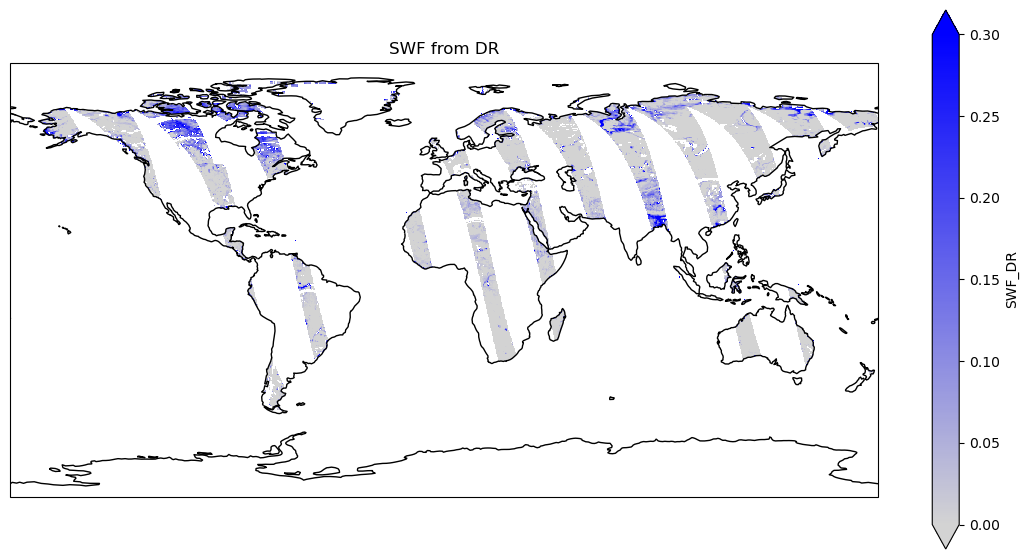

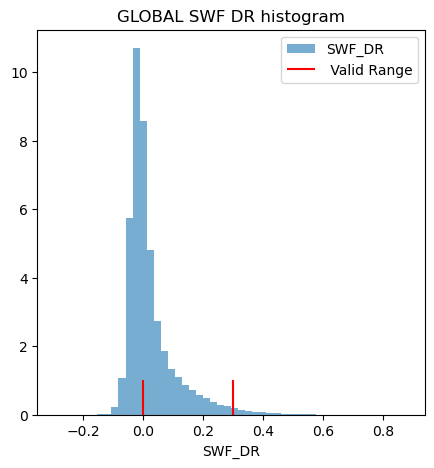

In [46]:
# Custom colormap for SWF
colors = ["#d3d3d3", "blue"]  # Gris claro en lugar de gris oscuro
cmap_ = LinearSegmentedColormap.from_list("LightGrayToBlue", colors)

fig, ax = plt.subplots(1, 1, figsize=(14, 7), subplot_kw={"projection": ccrs.PlateCarree(central_longitude=0)})

# Represents SWF in the range from 0 to 0.3
tds.SWF_DR.plot(ax=ax, vmin=0, vmax=0.3, cmap=cmap_)  # Filter from 0 to 0.3
ax.coastlines("110m")  
ax.set_title("SWF from DR")

# Histogram
fig, ax = plt.subplots(1, 1, figsize=(5,5))
hist_kwargs = {
    "bins": 50,
    "density": True,
    "alpha": 0.6
}

pred_hist = tds.SWF_DR.plot.hist(ax=ax, **hist_kwargs, label = "SWF_DR")
# lpdr_hist = tds.fwns.plot.hist(ax=ax, **hist_kwargs, label = "LPDR's FW")
ax.vlines(x=[0, 0.3], ymin=0, ymax=1, colors="red", label=" Valid Range")
ax.legend()
ax.set_title("GLOBAL SWF DR histogram")


### Maps of SWF and input SM, VOD, TB (18 GHz, 36 GHz) over NA

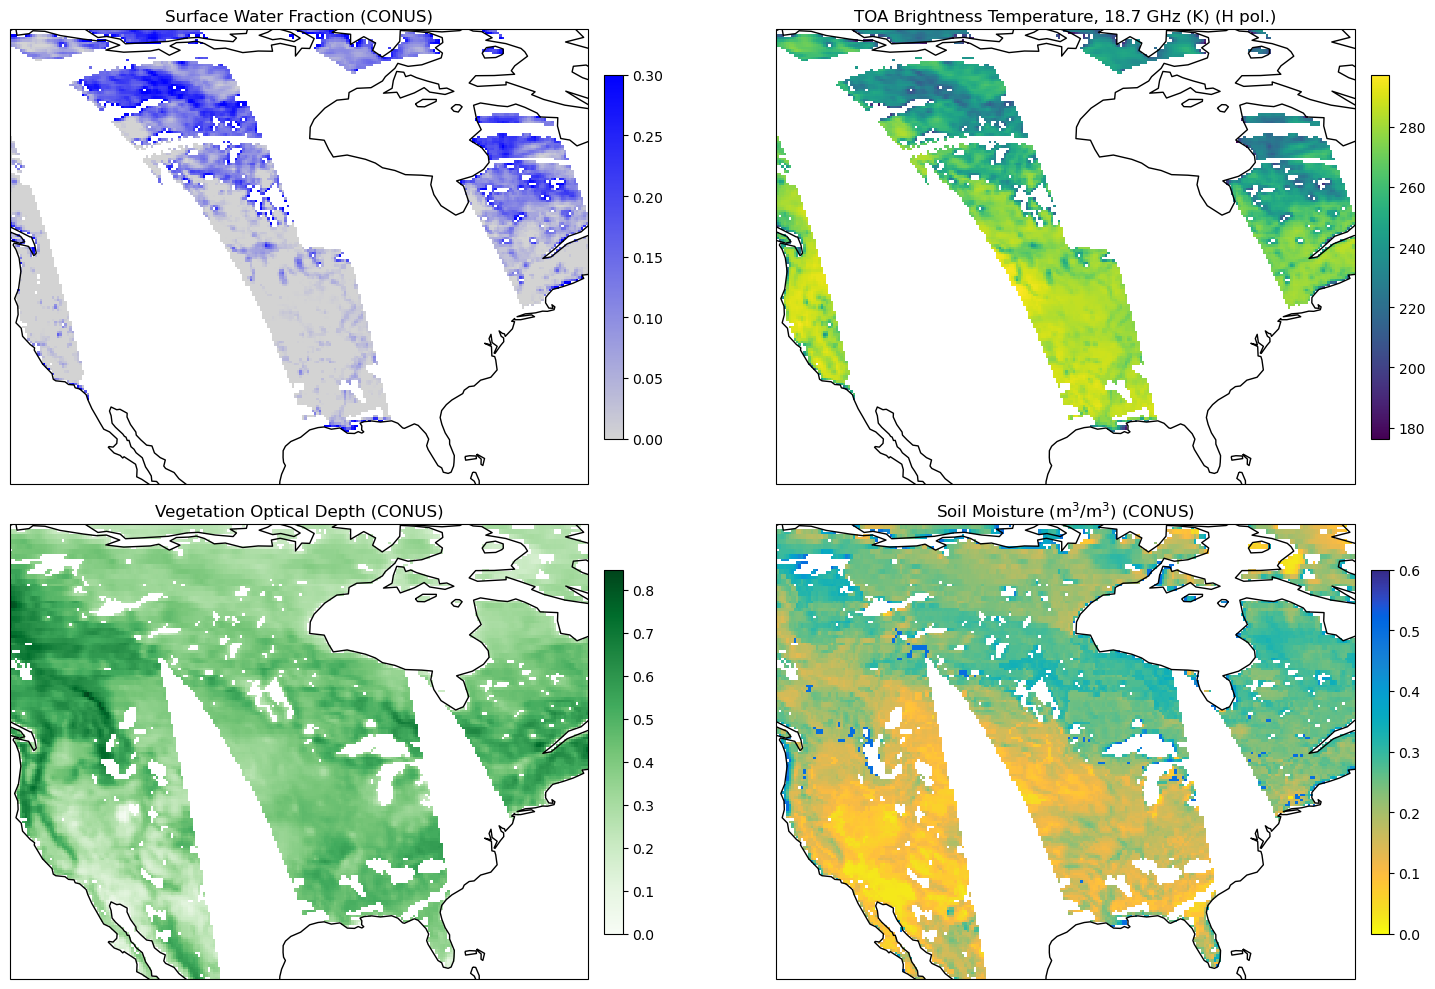

In [47]:
cmap_sm = colormaps.get_cm('parula')

to_plot_ds = tds.sel(lon=slice(-125, -66.5), lat=slice(24, 70))

fig = plt.figure(figsize=(16, 10))

axs = []
for i in range(4):
    ax = fig.add_subplot(2, 2, i+1, projection=ccrs.PlateCarree())
    ax.coastlines("110m")
    axs.append(ax)

# SWF
plot1 = to_plot_ds.SWF_DR.plot(ax=axs[0], vmin=0, vmax=0.3, cmap=cmap_, transform=ccrs.PlateCarree(), add_colorbar=False)
axs[0].set_title("Surface Water Fraction (CONUS)")

# Brightness temperature
plot2 = to_plot_ds.tbtoa19H.plot(ax=axs[1], transform=ccrs.PlateCarree(), add_colorbar=False)
axs[1].set_title("TOA Brightness Temperature, 18.7 GHz (K) (H pol.)")

# VOD
plot3 = to_plot_ds.VOD.plot(ax=axs[2], vmin=0, cmap='Greens', transform=ccrs.PlateCarree(), add_colorbar=False)
axs[2].set_title("Vegetation Optical Depth (CONUS)")

# Soil Moisture
plot4 = to_plot_ds.vsm.plot(ax=axs[3], vmin=0, vmax=0.6, cmap=cmap_sm, transform=ccrs.PlateCarree(), add_colorbar=False)
axs[3].set_title("Soil Moisture (m$^3$/m$^3$) (CONUS)")

for i, plot in enumerate([plot1, plot2, plot3, plot4]):
    cbar = fig.colorbar(plot, ax=axs[i], orientation='vertical', pad=0.02, shrink=0.8)
    cbar.set_label('')

plt.tight_layout()
plt.show()


Text(0.5, 0, '')

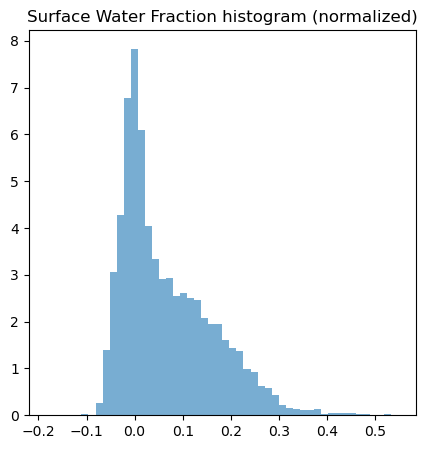

In [48]:
# Histogram
fig, ax = plt.subplots(1, 1, figsize=(5,5))

pred_hist = to_plot_ds.SWF_DR.plot.hist(ax=ax, **hist_kwargs, label = "SWF")
# lpdr_hist = to_plot_ds.fwns.plot.hist(ax=ax, **hist_kwargs, label = "LPDR's FW")
#ax.legend()
ax.set_title("Surface Water Fraction histogram (normalized)")
ax.set_xlabel('')

### Extended maps for Global coverage

Text(0.5, 1.0, 'NA SWF DR histogram')

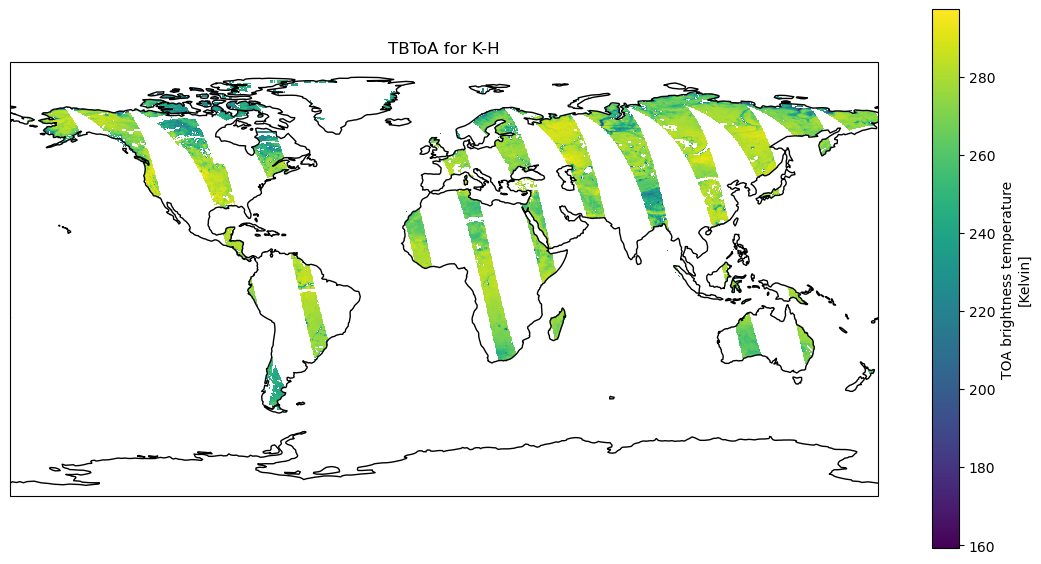

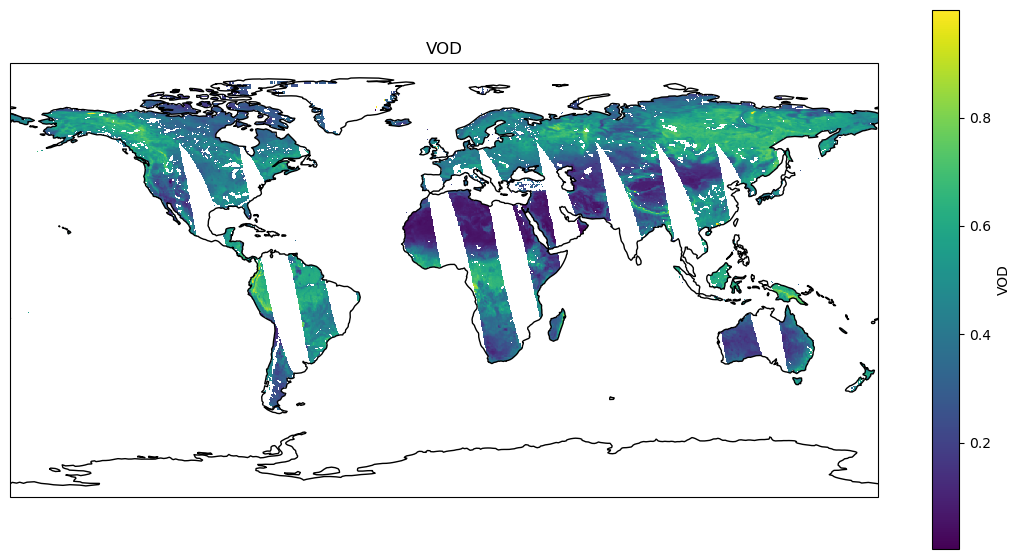

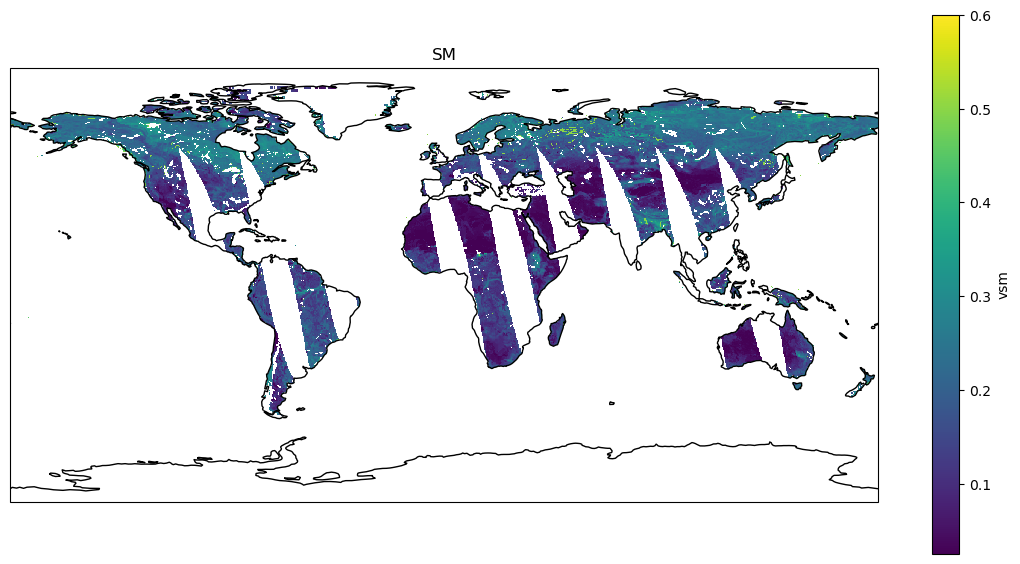

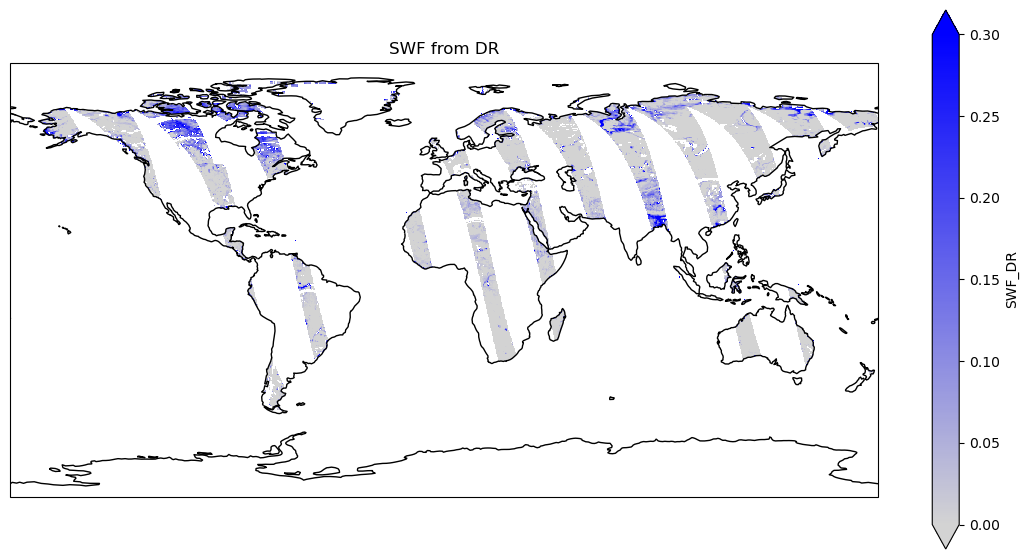

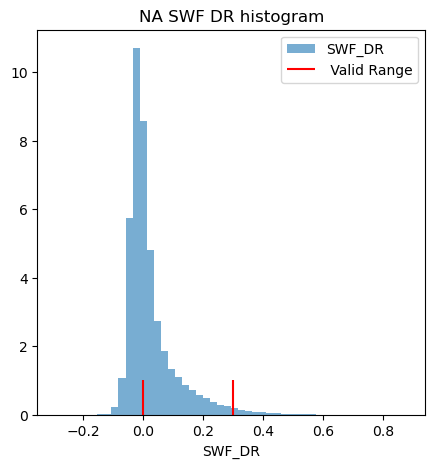

In [49]:
to_plot_ds = tds

def setup_map():
    fig, ax = plt.subplots(1, 1, figsize=(14, 7), 
                       subplot_kw={"projection": ccrs.PlateCarree()}
                       )
    ax.coastlines("110m") 
    return fig, ax

# Brightness temperature for K band H-pol.
fig, ax = setup_map()
to_plot_ds.tbtoa19H.plot(ax=ax)
ax.set_title("TBToA for K-H")

# VOD
fig, ax = setup_map()
to_plot_ds.VOD.plot(ax=ax)
ax.set_title("VOD")

# SM
fig, ax = setup_map()
to_plot_ds.vsm.plot(ax=ax)
ax.set_title("SM")

# Predicted SWF
fig, ax = setup_map()
to_plot_ds.SWF_DR.plot(ax=ax, vmin=0, vmax=0.3, cmap=cmap_)
ax.set_title("SWF from DR")

# Histogram
fig, ax = plt.subplots(1, 1, figsize=(5,5))
hist_kwargs = {
    "bins": 50,
    "density": True,
    "alpha": 0.6
}

pred_hist = to_plot_ds.SWF_DR.plot.hist(ax=ax, **hist_kwargs, label = "SWF_DR")
# lpdr_hist = to_plot_ds.fwns.plot.hist(ax=ax, **hist_kwargs, label = "LPDR's FW")
ax.vlines(x=[0, 0.3], ymin=0, ymax=1, colors="red", label=" Valid Range")
ax.legend()
ax.set_title("NA SWF DR histogram")